<a href="https://colab.research.google.com/github/dhimas-ra/football-project/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


matches = pd.read_csv("/content/drive/MyDrive/Predicting Match Win Probability Using Last 3 Matches Statistics/matches.csv", sep= ";")
h2h = pd.read_csv("/content/drive/MyDrive/Predicting Match Win Probability Using Last 3 Matches Statistics/h2h.csv", sep= ";")
xi_players = pd.read_csv("/content/drive/MyDrive/Predicting Match Win Probability Using Last 3 Matches Statistics/xi_mancity.csv", sep= ";")


In [32]:
print("Displaying matches dataframe:")
display(matches)

Displaying matches dataframe:


,team,opponent,goal_scored,possesion,goal_concended,shots,xg,result
0,Man City,West Ham,1,71,1,24,2.49,D
1,Man City,Real Madrid,1,54,2,22,2.47,L
2,Man City,Arsenal,2,62,0,10,1.17,W
3,Liverpool,Tottenham,1,63,1,17,1.70,D
4,Liverpool,Galatasaray,4,62,0,32,4.88,W
5,Liverpool,Brighton,1,53,2,12,2.17,L


In [33]:
print("Displaying Head to Head dataframe:")
display(h2h)

Displaying Head to Head dataframe:


,home,away,winner
0,Liverpool,Man City,Man City
1,Man City,Liverpool,Man City
2,Man City,Liverpool,Liverpool


In [31]:
print("Displaying xi_players dataframe:")
display(xi_players)

Displaying xi_players dataframe:


,team,player,position,goals,assists,avg_rating
0,Manchester City,Gianlugi Donnaruma,GK,0,0,5.85
1,Manchester City,Matheus Nunes,RB,0,0,6.30
2,Manchester City,Ruben Dias,CB,0,0,6.70
3,Manchester City,Abdukodir Khusanov,CB,0,0,6.60
4,Manchester City,Rayan Ait-Nouri,LB,0,0,6.30
5,Manchester City,Rodri,DM,0,0,7.10
6,Manchester City,Nico O'Reilly,CM,2,0,7.35
7,Manchester City,Bernardo Silva,AM,1,1,6.40
8,Manchester City,Rayan Cherki,RM,0,0,6.50
9,Manchester City,Antoine Semenyo,LM,0,1,6.65


In [34]:
city = matches[matches['team'] == 'Man City']
liverpool = matches[matches['team'] == 'Liverpool']

# LAST 3 MATCHES STATS
city_avg_goal = city['goal_scored'].mean()
city_concede = city['goal_concended'].mean()
city_avg_possesion = city['possesion'].mean()
city_avg_shots = city['shots'].mean()
city_avg_xg = city['xg'].mean()

liverpool_avg_goal = liverpool['goal_scored'].mean()
liverpool_concede = liverpool['goal_concended'].mean()
liverpool_avg_possesion = liverpool['possesion'].mean()
liverpool_avg_shots = liverpool['shots'].mean()
liverpool_avg_xg = liverpool['xg'].mean()

# 3 LAST H2H
city_liv_h2h = h2h[
    ((h2h['home'] == 'Liverpool') & (h2h['away'] == 'Man City')) |
    ((h2h['home'] == 'Man City') & (h2h['away'] == 'Liverpool')) |
    ((h2h['home'] == 'Man City') & (h2h['away'] == 'Liverpool'))
]

city_wins = (city_liv_h2h['winner'] == 'Man City').sum()
total_matches = len(city_liv_h2h)
h2h_city_winrate = city_wins / total_matches

liverpool_wins = (city_liv_h2h['winner'] == 'Liverpool').sum()
h2h_liverpool_winrate = liverpool_wins / total_matches

draws = (city_liv_h2h['winner'] == 'Draw').sum()

city_pos_score = city_avg_possesion / 100
liverpool_pos_score = liverpool_avg_possesion / 100

# PLAYERS H2H LAST 3 MATCHES
city_players = xi_players[xi_players['team'] == 'Manchester City'].copy()
liverpool_players = xi_players[xi_players['team'] == 'Liverpool'].copy()

city_players['impact'] = (
    city_players['goals'] * 0.3 +
    city_players['assists'] * 0.3 +
    city_players['avg_rating'] * 0.5
)

liverpool_players['impact'] = (
    liverpool_players['goals'] * 0.3 +
    liverpool_players['assists'] * 0.3 +
    liverpool_players['avg_rating'] * 0.5
)

city_player_score = city_players['impact'].mean()
liverpool_player_score = liverpool_players['impact'].mean()

# TEAM STRENGTH

city_strength = (
    city_avg_goal * 0.4 +
    city_avg_xg * 0.3 +
    city_avg_shots * 0.2 +
    city_pos_score * 0.1 +
    h2h_city_winrate * 0.3 +
    city_player_score * 0.2 -
    city_concede * 0.3
)

liverpool_strength = (
    liverpool_avg_goal * 0.4 +
    liverpool_avg_xg * 0.3 +
    liverpool_avg_shots * 0.2 +
    liverpool_pos_score * 0.1 +
    h2h_liverpool_winrate * 0.3 +
    liverpool_player_score * 0.2 -
    liverpool_concede * 0.3
)

# Draw Probabilty

city_strength = 5.53
liverpool_strength = 6.36

diff = abs(city_strength - liverpool_strength)

base_draw = 0.30
adjusment = 0.15

draw_prob = base_draw + (diff * adjusment)
draw_prob = max(0.10, draw_prob)

remaining_prob = 1 - draw_prob

# Probability

total = city_strength + liverpool_strength
city_prob = (city_strength / total) * remaining_prob
liverpool_prob = remaining_prob - city_prob

summary = pd.DataFrame({
    "Team": ["Manchester City", "Liverpool"],
    "Strength": [city_strength, liverpool_strength],
    "Win Probability": [city_prob, liverpool_prob],
})
summary["Win Probability (%)"] = (
   summary["Win Probability"] * 100
).round(1).astype(str) + "%"

summary = summary.drop(columns=["Win Probability"])

print(summary)

print("Draw Probability:", round(draw_prob*100,1), "%")

#print(f"Man City win probability: {city_prob:.2%}")
#print(f"Liverpool win probability: {liverpool_prob:.2%}")

              Team  Strength Win Probability (%)
0  Manchester City      5.53               26.8%
1        Liverpool      6.36               30.8%
Draw Probability: 42.4 %


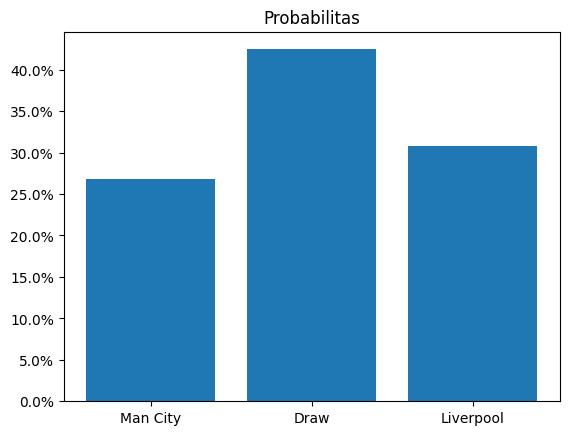

In [35]:
teams = ['Man City', 'Draw', 'Liverpool']
probs = [city_prob,draw_prob, liverpool_prob]

plt.bar(teams, probs)
plt.title("Probabilitas")

# Format y-axis as percentages
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.show()